In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

BASE_DIR = 'D:/Leonardo/UDESA - CENTRO Cuantitativo/EPU ARG/src'
save_results_dir = Path(BASE_DIR).parent / "data" / "results"

In [ ]:
results_base_file = save_results_dir / "epu_analysis_results_udesa_jp.xlsx"

df = pd.read_excel(results_base_file, sheet_name='EPU_Monthly')
df.set_index('fecha', inplace=True)
df[['positive_proportion', 'negative_proportion','neutral_proportion']] = df[['positive_proportion', 'negative_proportion','neutral_proportion']].mul(df["EPU UdeSA"], axis=0)

In [9]:
results_fiscal_file = save_results_dir / "subcategories" / "epu_analysis_results_udesa_jp_fiscal.xlsx"
results_currency_crisis_file = save_results_dir / "subcategories" / "epu_analysis_results_udesa_jp_currency_crisis.xlsx"
results_monetary_policy_file = save_results_dir / "subcategories" / "epu_analysis_results_udesa_jp_monetary_policy.xlsx"
results_trade_file = save_results_dir / "subcategories" / "epu_analysis_results_udesa_jp_trade.xlsx"

df_fiscal = pd.read_excel(results_fiscal_file, sheet_name='EPU_Monthly')
df_fiscal.set_index('fecha', inplace=True)
df_currency_crisis = pd.read_excel(results_currency_crisis_file, sheet_name='EPU_Monthly')
df_currency_crisis.set_index('fecha', inplace=True)
df_monetary_policy = pd.read_excel(results_monetary_policy_file, sheet_name='EPU_Monthly')
df_monetary_policy.set_index('fecha', inplace=True)
df_trade = pd.read_excel(results_trade_file, sheet_name='EPU_Monthly')
df_trade.set_index('fecha', inplace=True)

In [24]:
proportion = pd.DataFrame()
proportion["prop_fiscal"] = df_fiscal["EPU Counts"]
proportion["prop_currency_crisis"] = df_currency_crisis["EPU Counts"]
proportion["prop_monetary_policy"] = df_monetary_policy["EPU Counts"]
proportion["prop_trade"] = df_trade["EPU Counts"]
proportion["total"] = proportion.sum(axis=1)
proportion.index = df_fiscal.index
proportion = proportion.div(proportion["total"], axis=0).dropna() *100
proportion.drop(columns=["total"], axis = 0, inplace=True) 

In [27]:
df = df.loc[proportion.index]

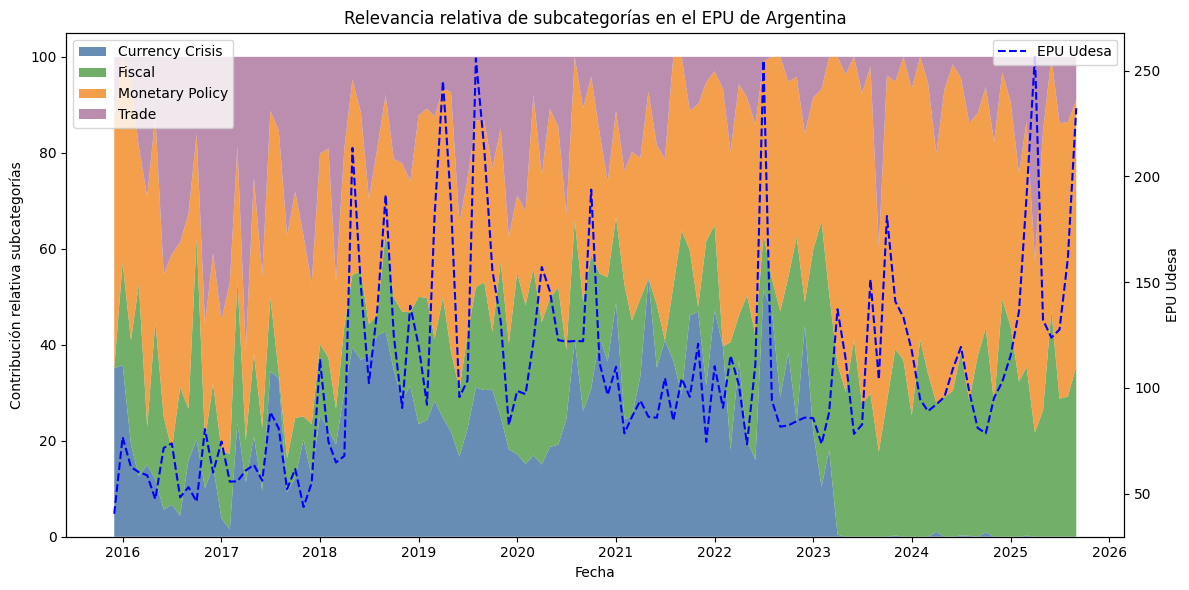

In [28]:
palette = ["#4E79A7", "#59A14F", "#F28E2B", "#B07AA1"]

fig, ax1 = plt.subplots(figsize=(12, 6))

cols = ['prop_currency_crisis','prop_fiscal','prop_monetary_policy','prop_trade']
labels = ['Currency Crisis', 'Fiscal', 'Monetary Policy', 'Trade']
stack = ax1.stackplot(
    proportion.index,
    *[proportion[c].values for c in cols],
    labels=labels,
    colors=palette,
    alpha=0.85
)

ax1.set_xlabel('Fecha')
ax1.set_ylabel('Contribución relativa subcategorías')
ax1.set_title('Relevancia relativa de subcategorías en el EPU de Argentina')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(df["EPU UdeSA"], color='blue', linestyle='--', label='EPU Udesa')
ax2.set_ylabel('EPU Udesa')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.0)

plt.tight_layout()
plt.show()

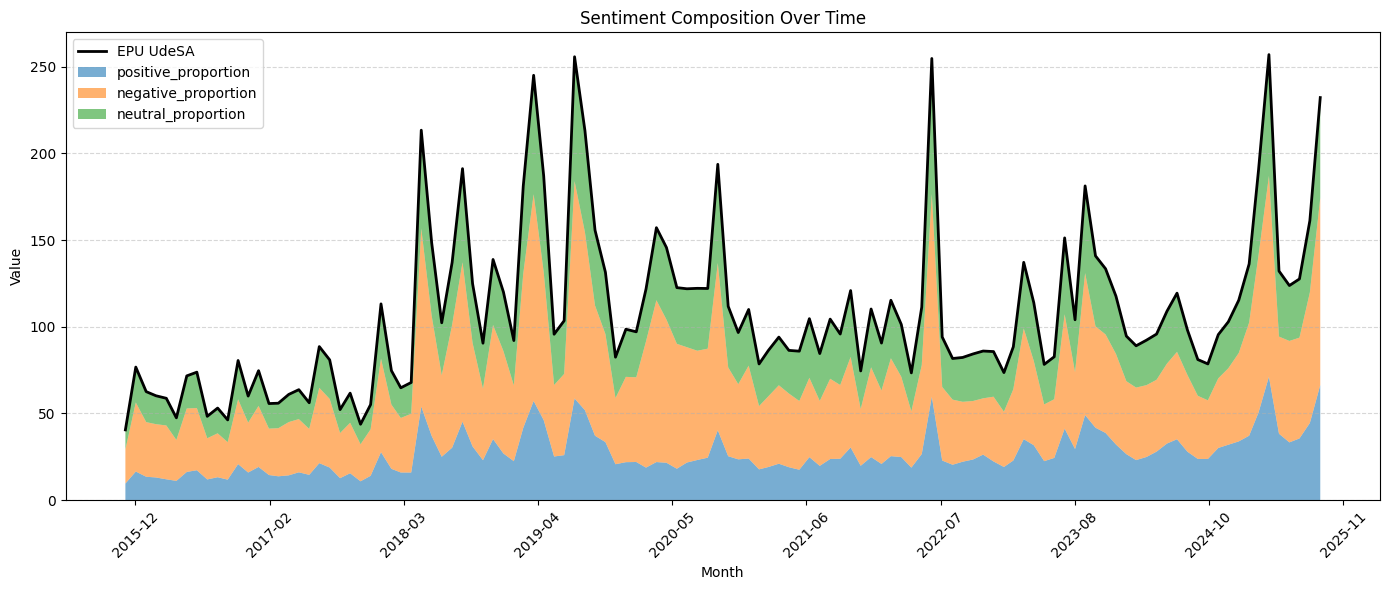

In [33]:
components = ['positive_proportion', 'negative_proportion','neutral_proportion']
components_names = ['Positive Sentiment', 'Negative Sentiment', 'Neutral Sentiment']



plt.figure(figsize=(14, 6))
plt.plot(df.index, df['EPU UdeSA'], color='black', label='EPU UdeSA', linewidth=2)
plt.stackplot(df.index,
              df[components].T,
              labels=components,
              alpha=0.6)

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=12))  # max 12 ticks
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

plt.title("Sentiment Composition Over Time")
plt.ylabel("Value")
plt.xlabel("Month")
plt.legend(loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()